# Brazilian E-Commerce 数据分析

基于 Olist 电商平台数据集，探索订单漏斗、客户留存、RFM 价值分层和商品类目表现。

**数据集**: 9 张表，涵盖客户、订单、支付、商品、卖家等维度
**分析工具**: pandas, matplotlib, pyecharts

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 中文字体配置 
plt.rcParams[ 'font.sans-serif' ] = [ 'SimHei' ]
plt.rcParams[ 'axes.unicode_minus' ] = False

from pathlib import Path
import os

pd.set_option('display.max_columns', None)

## 导入数据(9个) 并 清洗

In [128]:
# 定义数据路径（`data/raw/`）
RAW_DIR = Path(os.getcwd()) / ".." / "data" / "raw"
PROCESSED_DIR = Path(os.getcwd()) / ".." / "data" / "processed"

print(f"RAW_DIR: {RAW_DIR}")
print(f"存在: {RAW_DIR.exists()}")

RAW_DIR: e:\Git_program\data_project1\ecommerce-funnel-analysis\src\..\data\raw
存在: True


In [129]:
# 定义 9 个 CSV 文件名
files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

# 逐个读取，存入字典
data = {}
for key, filename in files.items():
    filepath = RAW_DIR / filename
    data[key] = pd.read_csv(filepath)
    print(f"  {key:<22} {data[key].shape[0]:>7} rows * {data[key].shape[1]} cols")

  customers                99441 rows * 5 cols
  geolocation            1000163 rows * 5 cols
  order_items             112650 rows * 7 cols
  order_payments          103886 rows * 5 cols
  order_reviews            99224 rows * 7 cols
  orders                   99441 rows * 8 cols
  products                 32951 rows * 9 cols
  sellers                   3095 rows * 4 cols
  category_translation        71 rows * 2 cols


### 1. 清洗 orders 表

In [130]:
# 查看 1. orders数据
orders = data['orders']
print(orders.head())
# 查看几行几列 
print (orders.shape) 



                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [131]:
# 转时间格式
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders = data['orders'].copy()
for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print(orders[timestamp_cols].dtypes)


print(orders[['order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date']].head())

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
  order_purchase_timestamp   order_approved_at order_delivered_carrier_date  \
0      2017-10-02 10:56:33 2017-10-02 11:07:15          2017-10-04 19:55:00   
1      2018-07-24 20:41:37 2018-07-26 03:24:27          2018-07-26 14:31:00   
2      2018-08-08 08:38:49 2018-08-08 08:55:23          2018-08-08 13:50:00   
3      2017-11-18 19:28:06 2017-11-18 19:45:59          2017-11-22 13:39:59   
4      2018-02-13 21:18:39 2018-02-13 22:20:29          2018-02-14 19:46:34   

  order_delivered_customer_date order_estimated_delivery_date  
0           2017-10-10 21:25:13                    2017-10-18  
1           2018-08-07 15:27:45                    2018-08-13  
2           2018-08-17 18:06:29                    2018-09-04  
3           201

In [132]:
# 查看几行几列 
print (orders.shape) 
# 每列的唯一值数量 
print(f"每列有多少个不同值")
print(orders.nunique())

print('----------')
# 检查缺失值
print(f"各列缺失值为:")
print(data['orders'].isna().sum())


(99441, 8)
每列有多少个不同值
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64
----------
各列缺失值为:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [133]:
print('订单状态分别为:')
print(orders[ 'order_status'].unique())
print("---------")
# 先看 order_status 的分布
print(orders['order_status'].value_counts())

# 看各状态下的时间缺失情况
orders.groupby('order_status')[timestamp_cols].apply(lambda x: x.isna().sum())

订单状态分别为:
['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
---------
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,
approved,0,0,2,2,0
canceled,0,141,550,619,0
created,0,5,5,5,0
delivered,0,14,2,8,0
invoiced,0,0,314,314,0
processing,0,0,301,301,0
shipped,0,0,0,1107,0
unavailable,0,0,609,609,0


In [134]:
# 删掉未闭环订单
before = len(orders)

orders = orders[~orders['order_status'].isin(['canceled', 'unavailable'])]
after = len(orders)

print(f"清洗后剩余: {len(orders)} 条订单, 清洗掉了{before - after}条订单")
orders['order_status'].value_counts()

清洗后剩余: 98207 条订单, 清洗掉了1234条订单


order_status
delivered     96478
shipped        1107
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

In [135]:
# 增加4列衍生列：日期、月份、小时、星期
orders['purchase_date'] = orders['order_purchase_timestamp'].dt.date
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour
orders['purchase_dow'] = orders['order_purchase_timestamp'].dt.day_name()


print(type(orders[['purchase_date', 'purchase_month', 'purchase_hour', 'purchase_dow']]))
print(orders[['purchase_date', 'purchase_month', 'purchase_hour', 'purchase_dow']].dtypes)

print(orders[['purchase_date', 'purchase_month', 'purchase_hour', 'purchase_dow']].head())
print(orders.shape)
print(orders.head())




<class 'pandas.core.frame.DataFrame'>
purchase_date        object
purchase_month    period[M]
purchase_hour         int32
purchase_dow         object
dtype: object
  purchase_date purchase_month  purchase_hour purchase_dow
0    2017-10-02        2017-10             10       Monday
1    2018-07-24        2018-07             20      Tuesday
2    2018-08-08        2018-08              8    Wednesday
3    2017-11-18        2017-11             19     Saturday
4    2018-02-13        2018-02             21      Tuesday
(98207, 12)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_t

In [136]:
# 查看 2.customers表
print(data['customers'].shape)
print(data['customers'].head())
customers = data['customers']

# 每列的唯一值数量 
print(f"每列有多少个不同值")
print(customers.nunique())
# 不同的订单, 即便是同一个人仍然是不同的客户id

print('----------')
# 检查缺失值
print(f"各列缺失值为:")
print(data['customers'].isna().sum())

print('orders 列:', orders.columns.tolist())
print('customers 列:', customers.columns.tolist())

(99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
每列有多少个不同值
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4

In [137]:
# 合并 customer_unique_id（真实客户标识）
orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
print(orders.shape)
orders.head()

(98207, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_month,purchase_hour,purchase_dow,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017-10,10,Monday,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018-07,20,Tuesday,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018-08,8,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017-11,19,Saturday,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018-02,21,Tuesday,72632f0f9dd73dfee390c9b22eb56dd6


### 2. 清洗 order_items 表

In [138]:
# 3.order_items 表探索
print(data['order_items'].shape)
print(data['order_items'].head())
print(data['order_items'].nunique())
print(data['order_items'].isna().sum())

(112650, 7)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99  

In [139]:
# 查看 4.products表
products = data['products'].copy()
print(products.shape)
# print(products.head())
print(products.nunique())
print(f"--------")
print(products.isna().sum())

(32951, 9)
product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64
--------
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [140]:
# 查看 5.category_translation 表
category_translation = data['category_translation'].copy()
print(category_translation.shape)
print(category_translation.head())
print(category_translation.nunique())
print(category_translation.isna().sum())

# 找 translation 表中两列值相同的行
mask = data['category_translation']['product_category_name'] == data['category_translation']['product_category_name_english']
print(f"两列相同的行数: {mask.sum()}")
data['category_translation'][mask]

(71, 2)
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
product_category_name            71
product_category_name_english    71
dtype: int64
product_category_name            0
product_category_name_english    0
dtype: int64
两列相同的行数: 7


,product_category_name,product_category_name_english
19,consoles_games,consoles_games
20,audio,audio
22,cool_stuff,cool_stuff
29,pet_shop,pet_shop
31,market_place,market_place
60,la_cuisine,la_cuisine
65,dvds_blu_ray,dvds_blu_ray


In [141]:
# products 表中非空的类目名
product_cats = data['products']['product_category_name'].dropna().unique()
# translation 表中的类目名
translation_cats = data['category_translation']['product_category_name'].unique()

# products 有但 translation 没有的
in_product_not_translation = set(product_cats) - set(translation_cats)
print(f"products 有但 translation 没有的: {len(in_product_not_translation)} 种")
print(in_product_not_translation)

# translation 有但 products 没用到的
in_translation_not_product = set(translation_cats) - set(product_cats)
print(f"\ntranslation 有但 products 没用到的: {len(in_translation_not_product)} 种")
print(in_translation_not_product)

products 有但 translation 没有的: 2 种
{'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}

translation 有但 products 没用到的: 0 种
set()


In [142]:
# 清洗 order_items
items = data['order_items'].copy()

# 合并 products 表，拿类目名
items = items.merge(
    products[['product_id', 'product_category_name']], 
    on='product_id', 
    how='left'
)

# 合并翻译表，翻译成英文
items = items.merge(
    category_translation, 
    on='product_category_name', 
    how='left'
)

# 添加英文类目列，翻译缺失的用原名
items['category_en'] = items['product_category_name_english'].fillna(items['product_category_name'])

print(items.shape)
items.head()

(112650, 10)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,category_en
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,garden_tools


In [143]:
# 找两列相同的行 
mask = items[ 'product_category_name' ] == items[ 'product_category_name_english' ]
same_rows = items[mask] 
print(f"一共有 {same_rows['product_category_name'].nunique()} 种重复")
# 看有多少种不同的重复值 
print(same_rows[ 'product_category_name' ].value_counts())

print(items[['product_category_name', 'product_category_name_english', 'category_en']].nunique())



一共有 7 种重复
product_category_name
cool_stuff        3796
pet_shop          1947
consoles_games    1137
audio              364
market_place       311
dvds_blu_ray        64
la_cuisine          14
Name: count, dtype: int64
product_category_name            73
product_category_name_english    71
category_en                      73
dtype: int64


In [144]:
print(items.shape)
# print(items.head())
print(items.nunique())
print(f"-------------------")
print(items.isna().sum())

(112650, 10)
order_id                         98666
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
product_category_name               73
product_category_name_english       71
category_en                         73
dtype: int64
-------------------
order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1603
product_category_name_english    1627
category_en                      1603
dtype: int64


In [145]:
# 填充 category_en 缺失值
items['category_en'] = items['category_en'].fillna('unknown')

# 转时间格式
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')

# 确认
print(items['category_en'].isna().sum())
print(items['shipping_limit_date'].dtypes)

0
datetime64[ns]


In [146]:
# 查看 6. order_payments 表
order_payments = data['order_payments'].copy()
print(order_payments.shape)
print(order_payments.head())
print(order_payments.nunique())
# print(order_payments['payment_type'].value_counts())
print(f"--------")
print(order_payments.isna().sum())

(103886, 5)
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64
--------
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


### 3.创建主表 master

In [147]:
# 合并 payments（按 order_id 汇总支付金额）
payment_agg = data['order_payments'].groupby('order_id')['payment_value'].sum().reset_index()
payment_agg.columns = ['order_id', 'total_payment']
master = orders.merge(payment_agg, on='order_id', how='left')

# 3. 合并 customers（加 customer_state） 
master = master.merge(
    customers[[ 'customer_id' , 'customer_state' ]],
    on= 'customer_id' ,
    how= 'left' ) 
print ( f"master: {master.shape} " )
master.head()

master: (98207, 15) 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_month,purchase_hour,purchase_dow,customer_unique_id,total_payment,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017-10,10,Monday,7c396fd4830fd04220f754e42b4e5bff,38.71,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018-07,20,Tuesday,af07308b275d755c9edb36a90c618231,141.46,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018-08,8,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8,179.12,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017-11,19,Saturday,7c142cf63193a1473d2e66489a9ae977,72.20,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018-02,21,Tuesday,72632f0f9dd73dfee390c9b22eb56dd6,28.62,SP


In [148]:
print(payment_agg.shape)
print(payment_agg.head())
print(payment_agg.nunique())
print(payment_agg.isna().sum())



(99440, 2)
                           order_id  total_payment
0  00010242fe8c5a6d1ba2dd792cb16214          72.19
1  00018f77f2f0320c557190d7a144bdd3         259.83
2  000229ec398224ef6ca0657da4fc703e         216.87
3  00024acbcdf0a6daa1e931b038114c75          25.78
4  00042b26cf59d7ce69dfabb4e55b4fd9         218.04
order_id         99440
total_payment    27979
dtype: int64
order_id         0
total_payment    0
dtype: int64


## 2.数据分析

- 1. 漏斗分析

In [149]:
# 订单漏斗
total = len(master)
funnel = pd.DataFrame({
    "stage": ["created", "approved", "shipped", "delivered"],
    "count": [
        total,
        master["order_approved_at"].notna().sum(),
        master["order_delivered_carrier_date"].notna().sum(),
        master["order_delivered_customer_date"].notna().sum(),
    ],
})
funnel["conversion_rate"] = (funnel["count"] / total * 100).round(2)
funnel

,stage,count,conversion_rate
0,created,98207,100.00
1,approved,98188,99.98
2,shipped,97583,99.36
3,delivered,96470,98.23


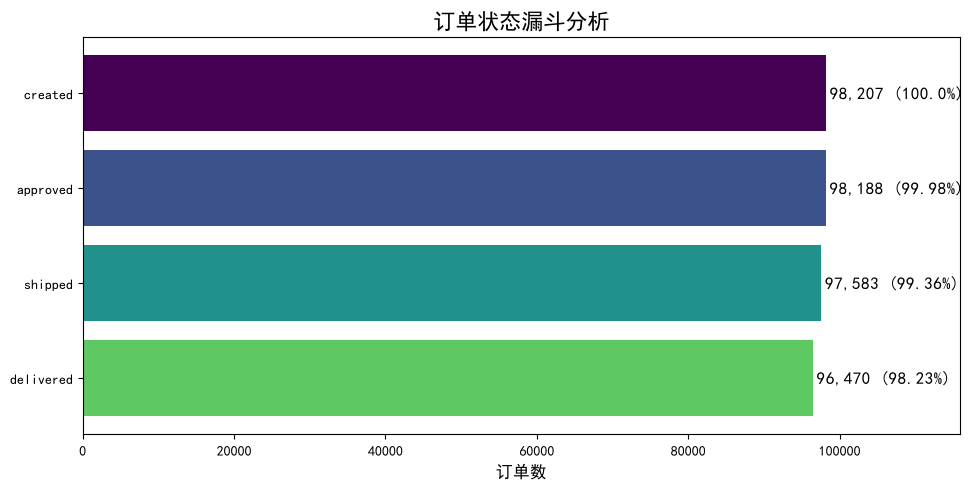

In [150]:
# 漏斗分析图（横向柱状图）
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#440154', '#3b528b', '#21918c', '#5ec962']
bars = ax.barh(funnel['stage'], funnel['count'], color=colors)

for bar, count, rate in zip(bars, funnel['count'], funnel['conversion_rate']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({rate}%)', va='center', fontsize=12)

ax.set_xlabel('订单数', fontsize=12)
ax.set_title('订单状态漏斗分析', fontsize=16)
ax.invert_yaxis()
ax.set_xlim(0, funnel['count'].max() * 1.18)
plt.tight_layout()
plt.show()


**分析结论：**
- 98,207 条正常订单中，99.98% 通过审批，99.36% 成功发货，98.23% 最终送达
- 整体转化率很高，从创建到送达仅流失 1.77%
- 审批环节几乎无流失（仅 19 条未审批），发货环节流失稍多（624 条未发货）
- 送达环节流失最大（1,113 条已发货未送达），可能是仍在途中的订单

- 2. 配送绩效分析: 统计准时率、延迟率、平均配送时间：

In [151]:
# 配送绩效
delivered = master.dropna(subset=['order_delivered_customer_date']).copy()

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days

total_delivered = len(delivered)
on_time = (delivered['delay_days'] <= 0).sum()
delayed = (delivered['delay_days'] > 0).sum()

print(f"已送达: {total_delivered}")
print(f"准时送达: {on_time} ({on_time/total_delivered*100:.2f}%)")
print(f"延迟送达: {delayed} ({delayed/total_delivered*100:.2f}%)")
print(f"平均配送时间: {delivered['delivery_days'].mean():.1f} 天")
print(f"平均提前送达天数: {- delivered['delay_days'].mean():.1f} 天")

已送达: 96470
准时送达: 89936 (93.23%)
延迟送达: 6534 (6.77%)
平均配送时间: 12.1 天
平均提前送达天数: 11.9 天


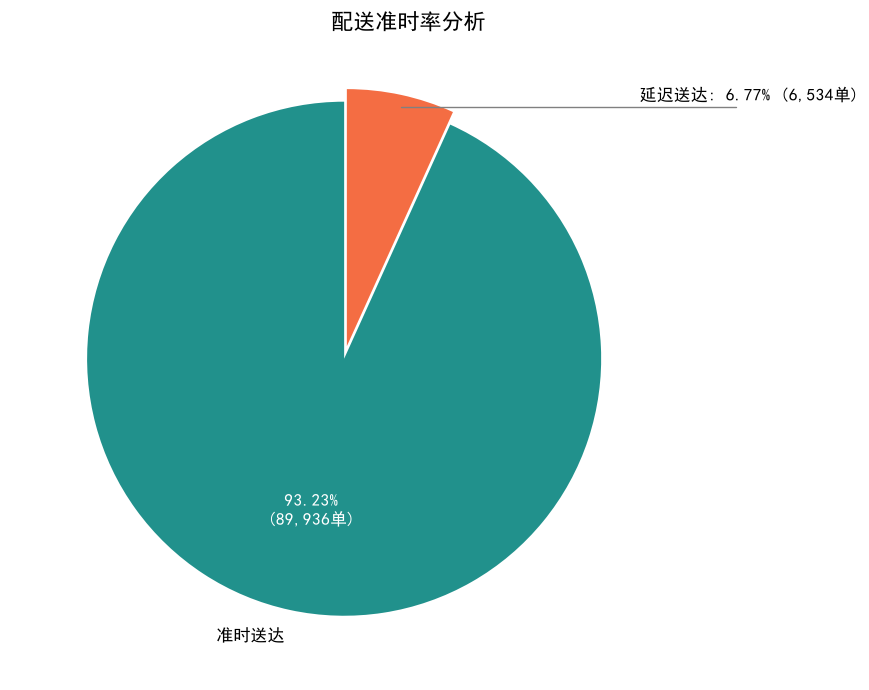

In [152]:
# 配送准时率饼图
fig, ax = plt.subplots(figsize=(11, 7))
labels = ['准时送达', '延迟送达']
sizes = [on_time, delayed]
colors = ['#21918c', '#f46d43']
explode = (0, 0.05)
total = total_delivered

pie_labels = [l if s / total * 100 >= 10 else '' for l, s in zip(labels, sizes)]

wedges, texts = ax.pie(sizes, explode=explode, labels=pie_labels, colors=colors,
    startangle=90, labeldistance=1.1,
    textprops={'fontsize': 12, 'fontweight': 'bold'})

for i, w in enumerate(wedges):
    p = sizes[i] / total * 100
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.radians(ang))
    y = np.sin(np.radians(ang))
    if p >= 10:
        ax.text(0.6 * x, 0.6 * y, f'{p:.2f}%\n({sizes[i]:,}单)',
                ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    else:
        ax.annotate(f'{labels[i]}: {p:.2f}% ({sizes[i]:,}单)',
                    xy=(x, y), xytext=(1.15, y + 0.05),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=1,
                                    connectionstyle='angle,angleA=45,angleB=0,rad=0'),
                    ha='left', va='center', fontsize=12, fontweight='bold')

ax.set_title('配送准时率分析', fontsize=16, fontweight='bold')
ax.set_xlim(-1.3, 1.8)
plt.tight_layout()
plt.show()


**分析结论：**
- 96,470 条已送达订单中，93.23% 准时送达，仅 6.77% 延迟
- 平均配送时间 12.1 天，平台预估日期较保守，平均提前 11.9 天送达
- 配送效率很高，延迟率控制在 7% 以内，用户体验良好

- 3.支付方式分析

In [153]:
#查看 order_payments 表
# print(order_payments.head())
# print(order_payments[].nunique)

# 支付方式分析
payment_stats = data['order_payments'].groupby('payment_type').agg(
    count=('payment_value', 'count'),
    total_amount=('payment_value', 'sum'),
    avg_amount=('payment_value', 'mean'),
).reset_index()

total_payments = payment_stats['total_amount'].sum()
payment_stats['share'] = (payment_stats['total_amount'] / total_payments * 100).round(2)
payment_stats = payment_stats.sort_values('total_amount', ascending=False)

payment_stats
# data['order_payments']['payment_sequential'].value_counts()

,payment_type,count,total_amount,avg_amount,share
1,credit_card,76795,12542084.19,163.319021,78.34
0,boleto,19784,2869361.27,145.034435,17.92
4,voucher,5775,379436.87,65.703354,2.37
2,debit_card,1529,217989.79,142.570170,1.36
3,not_defined,3,0.00,0.000000,0.00


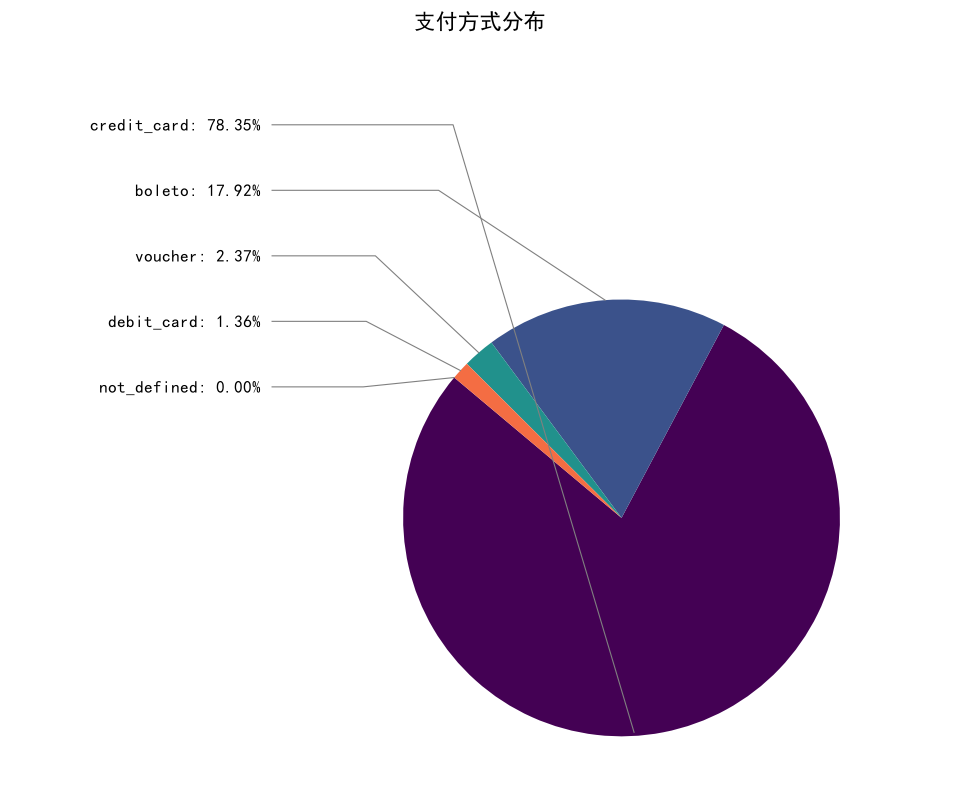

In [154]:
# 支付方式分布饼图
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#440154', '#3b528b', '#21918c', '#f46d43', '#a5a5a5']
labels = payment_stats['payment_type'].tolist()
sizes = payment_stats['share'].tolist()
total_pay = sum(sizes)

wedges, texts = ax.pie(sizes, labels=['']*len(labels), colors=colors,
    startangle=140, labeldistance=1.05)

label_x = -1.6
y_positions = [1.8, 1.5, 1.2, 0.9, 0.6]
for i, w in enumerate(wedges):
    p = sizes[i] / total_pay * 100
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.radians(ang))
    y = np.sin(np.radians(ang))
    if x > 0:
        x_edge = np.cos(np.radians(ang)) * 0.3
    else:
        x_edge = x
    mid_y = y_positions[i]
    mid_x = (x_edge + label_x) / 2
    ax.plot([x_edge, mid_x, label_x], [y, mid_y, mid_y], color='gray', lw=0.8)
    ax.text(label_x - 0.05, mid_y, f'{labels[i]}: {p:.2f}%',
            ha='right', va='center', fontsize=12, fontweight='bold')

ax.set_title('支付方式分布', fontsize=16, fontweight='bold')
ax.set_xlim(-2.8, 1.5)
ax.set_ylim(-1.2, 2.2)
plt.tight_layout()
plt.show()


**分析结论：**
- 信用卡占绝对主导地位，贡献 78.34% 的支付金额
- Boleto（巴西银行汇票）占 17.92%，是第二大支付方式
- 代金券和借记卡占比极低（2.37% 和 1.36%），not_defined 可忽略
- 信用卡+Boleto 合计占 96%，建议优先保障这两种支付渠道的稳定性

- 4.购买时间分析。按小时、星期、月份统计订单量：

In [155]:
# 购买时间分析
hourly = master.groupby('purchase_hour').size().reset_index(name='orders')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = master.groupby('purchase_dow').size().reset_index(name='orders').set_index('purchase_dow').reindex(day_order).reset_index()

monthly = master.groupby('purchase_month').size().reset_index(name='orders')

print("按小时分布:")
print(hourly)
print("\n按星期分布:")
print(daily)
print("\n按月分布:")
print(monthly)

按小时分布:
    purchase_hour  orders
0               0    2362
1               1    1154
2               2     503
3               3     267
4               4     205
5               5     185
6               6     493
7               7    1218
8               8    2939
9               9    4712
10             10    6083
11             11    6498
12             12    5918
13             13    6431
14             14    6491
15             15    6370
16             16    6594
17             17    6074
18             18    5707
19             19    5899
20             20    6116
21             21    6146
22             22    5761
23             23    4081

按星期分布:
  purchase_dow  orders
0       Monday   15979
1      Tuesday   15760
2    Wednesday   15353
3     Thursday   14571
4       Friday   13949
5     Saturday   10764
6       Sunday   11831

按月分布:
   purchase_month  orders
0         2016-09       2
1         2016-10     293
2         2016-12       1
3         2017-01     787
4         2017

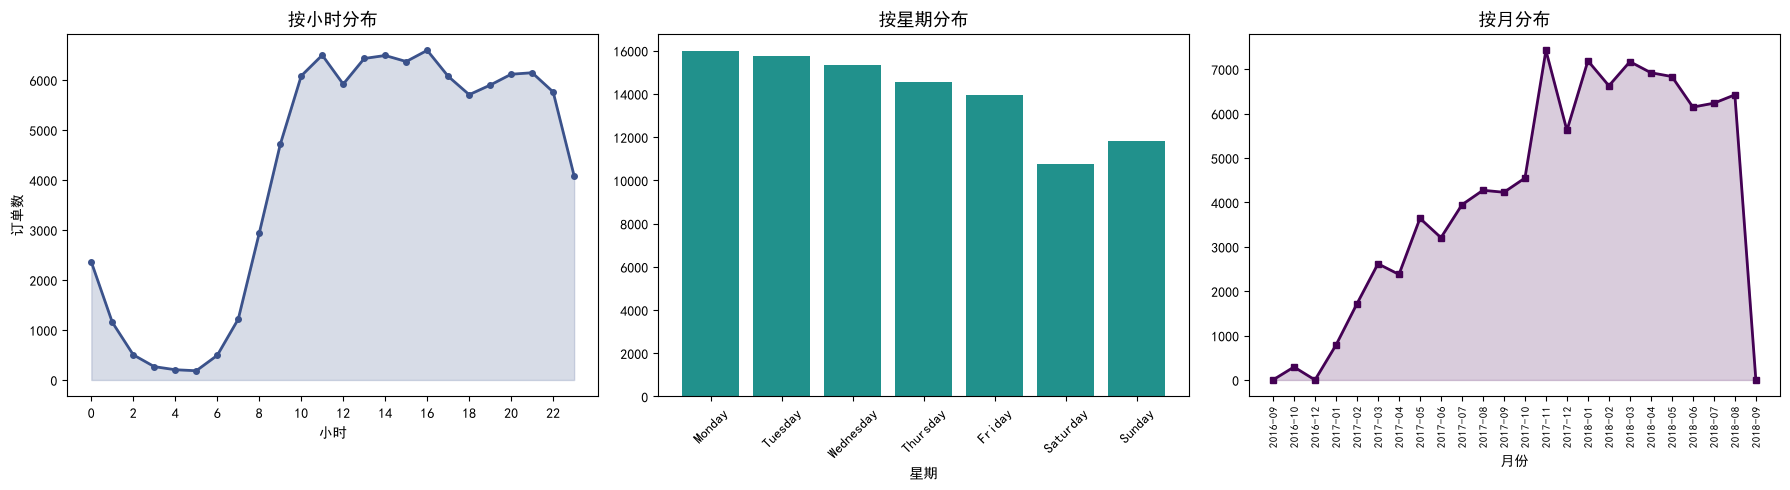

In [156]:
# 购买时间分析图（小时折线 + 星期柱状 + 月度折线）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hourly['purchase_hour'], hourly['orders'], marker='o', color='#3b528b', linewidth=2, markersize=4)
axes[0].fill_between(hourly['purchase_hour'], hourly['orders'], alpha=0.2, color='#3b528b')
axes[0].set_title('按小时分布', fontsize=13)
axes[0].set_xlabel('小时')
axes[0].set_ylabel('订单数')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(daily['purchase_dow'], daily['orders'], color='#21918c')
axes[1].set_title('按星期分布', fontsize=13)
axes[1].set_xlabel('星期')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(range(len(monthly)), monthly['orders'], marker='s', color='#440154', linewidth=2, markersize=4)
axes[2].fill_between(range(len(monthly)), monthly['orders'], alpha=0.2, color='#440154')
axes[2].set_title('按月分布', fontsize=13)
axes[2].set_xlabel('月份')
axes[2].set_xticks(range(len(monthly)))
axes[2].set_xticklabels([str(m) for m in monthly['purchase_month']], rotation=90, fontsize=8)

plt.tight_layout()
plt.show()


**分析结论：**
- 按小时：10-22 点为高峰时段，11-16 点最活跃，凌晨 3-5 点最低
- 按星期：周一到周三订单最多，周末明显下降（周六最低）
- 按月：2017年11月订单量最高（7,423），可能与促销活动有关；整体呈增长趋势，2018年保持稳定

- 5.同期群留存分析

In [157]:
# 同期群分析：按首次购买月份分组
first_purchase = master.groupby('customer_unique_id')['purchase_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']
# print(first_purchase)
master = master.merge(first_purchase, on='customer_unique_id', how='left')

# 看每个同期群有多少客户
cohort_sizes = master.groupby('cohort_month')['customer_unique_id'].nunique().reset_index(name='cohort_size')
print(cohort_sizes)

   cohort_month  cohort_size
0       2016-09            2
1       2016-10          290
2       2016-12            1
3       2017-01          752
4       2017-02         1690
5       2017-03         2571
6       2017-04         2325
7       2017-05         3541
8       2017-06         3102
9       2017-07         3822
10      2017-08         4130
11      2017-09         4075
12      2017-10         4392
13      2017-11         7190
14      2017-12         5439
15      2018-01         6951
16      2018-02         6357
17      2018-03         6931
18      2018-04         6698
19      2018-05         6586
20      2018-06         5920
21      2018-07         6016
22      2018-08         6209


In [158]:
# 计算每个客户每笔订单距离首次购买几个月
master['cohort_index'] = (
    master['purchase_month'].astype('int64') - master['cohort_month'].astype('int64')
)
# master['cohort_index'].value_counts()
# 留存矩阵：行=首次购买月，列=第几个月，值=有多少不同客户还在买
retention = master.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index(name='users')
# retention
retention = retention.pivot(index='cohort_month', columns='cohort_index', values='users')
retention

# # 转成留存率：除以同期群大小
# cohort_sizes_dict = cohort_sizes.set_index('cohort_month')['cohort_size']
# retention_rate = retention.div(cohort_sizes_dict, axis=0).round(4) * 100
retention_rate = retention.div(retention[0], axis=0).round(4) * 100
# 
retention_rate

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.34,NaN,NaN,0.34,NaN,0.34,NaN,0.34,NaN,0.34,NaN,0.34,0.69,0.69
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.40,0.27,0.13,0.40,0.13,0.40,0.13,0.13,NaN,0.40,0.13,0.66,0.40,0.13,0.13,0.27,0.40,0.13,NaN
2017-02,100.0,0.24,0.30,0.12,0.41,0.12,0.24,0.18,0.12,0.18,0.12,0.30,0.12,0.18,0.12,0.06,0.06,0.24,NaN,NaN
2017-03,100.0,0.51,0.35,0.39,0.35,0.16,0.16,0.31,0.35,0.08,0.39,0.12,0.23,0.12,0.16,0.23,0.08,0.16,NaN,NaN
2017-04,100.0,0.60,0.22,0.17,0.30,0.26,0.34,0.30,0.30,0.17,0.26,0.09,0.09,0.04,0.09,0.09,0.13,NaN,NaN,NaN
2017-05,100.0,0.48,0.48,0.40,0.31,0.34,0.42,0.14,0.25,0.25,0.25,0.34,0.25,0.03,0.20,0.23,NaN,NaN,NaN,NaN
2017-06,100.0,0.45,0.35,0.39,0.26,0.39,0.35,0.23,0.13,0.23,0.32,0.32,0.16,0.13,0.19,NaN,NaN,NaN,NaN,NaN


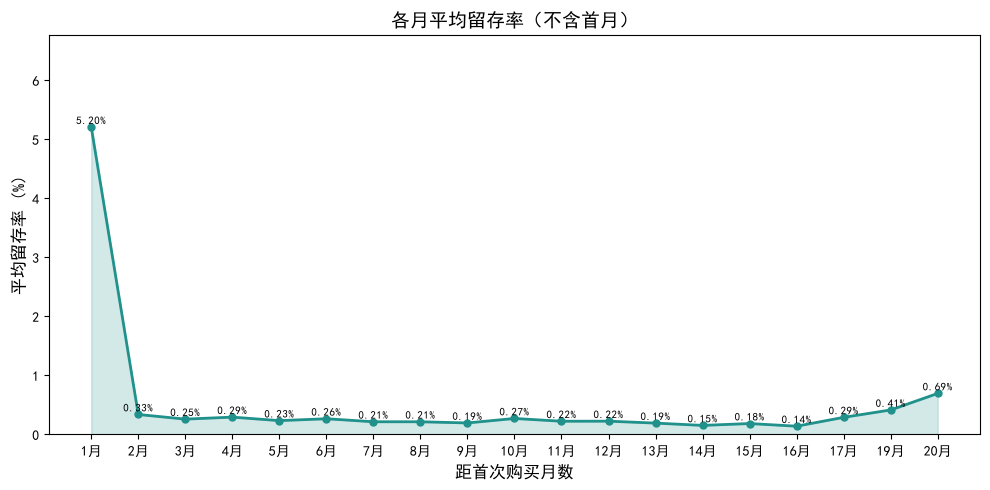

In [159]:
# 同期留存率折线图
fig, ax = plt.subplots(figsize=(10, 5))

avg_retention = retention_rate.mean().drop(0)
x_labels = avg_retention.index.astype(int)

ax.plot(range(len(avg_retention)), avg_retention.values, marker='o', color='#21918c', linewidth=2, markersize=5)
ax.fill_between(range(len(avg_retention)), avg_retention.values, alpha=0.2, color='#21918c')
ax.set_title('各月平均留存率（不含首月）', fontsize=14, fontweight='bold')
ax.set_xlabel('距首次购买月数', fontsize=12)
ax.set_ylabel('平均留存率 (%)', fontsize=12)
ax.set_xticks(range(len(avg_retention)))
ax.set_xticklabels([f'{int(i)}月' for i in x_labels])
for i, v in enumerate(avg_retention.values):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=8)
ax.set_ylim(0, avg_retention.max() * 1.3)
plt.tight_layout()
plt.show()


**分析结论：**
- 第 1 个月平均留存率 5.20%，即新客户次月回访概率约 5%
- 第 2 个月骤降至 0.33%，之后各月维持在 0.1%-0.5% 之间
- 第 10 个月之后留存率趋近于 0，几乎无客户长期复购
- 整体呈快速衰减趋势，95% 以上的客户首次购买后不再回访
- 平台增长高度依赖拉新获客，而非老客户复购
- 建议：优化首次购买体验，通过优惠券或会员体系提升次月留存率，重点维护那 5% 的回访客户

- 6.复购率

In [160]:
# 复购率
customer_orders = master.groupby('customer_unique_id')['order_id'].nunique()

repurchase_rate = (customer_orders > 1).sum() / len(customer_orders) * 100
print(f"总客户数: {len(customer_orders)}")
print(f"购买2次以上: {(customer_orders > 1).sum()}")
print(f"复购率: {repurchase_rate:.2f}%")

总客户数: 94990
购买2次以上: 2888
复购率: 3.04%


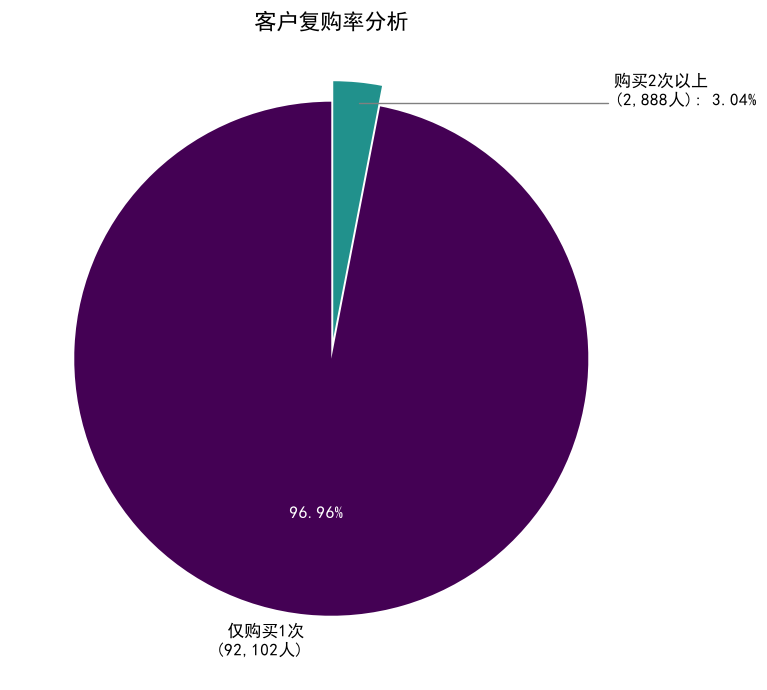

In [161]:
# 客户复购率饼图
fig, ax = plt.subplots(figsize=(11, 7))
total_customers = len(customer_orders)
single_count = (customer_orders == 1).sum()
repeat_count = (customer_orders > 1).sum()
labels = [f'仅购买1次\n({single_count:,}人)', f'购买2次以上\n({repeat_count:,}人)']
sizes = [single_count, repeat_count]
colors = ['#440154', '#21918c']
explode = (0, 0.08)

pie_labels = [l if s / total_customers * 100 >= 10 else '' for l, s in zip(labels, sizes)]

wedges, texts = ax.pie(sizes, explode=explode, labels=pie_labels, colors=colors,
    startangle=90, labeldistance=1.1,
    textprops={'fontsize': 12, 'fontweight': 'bold'})

for i, w in enumerate(wedges):
    p = sizes[i] / total_customers * 100
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.radians(ang))
    y = np.sin(np.radians(ang))
    if p >= 10:
        ax.text(0.6 * x, 0.6 * y, f'{p:.2f}%',
                ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    else:
        ax.annotate(f'{labels[i]}: {p:.2f}%',
                    xy=(x, y), xytext=(1.1, y + 0.05),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=1,
                                    connectionstyle='angle,angleA=45,angleB=0,rad=0'),
                    ha='left', va='center', fontsize=12, fontweight='bold')

ax.set_title('客户复购率分析', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**分析结论：**
- 94,990 个客户中，仅 2,888 个客户购买 2 次以上
- 复购率仅 3.04%，近 97% 客户为一次性消费
- 电商平台复购率普遍偏低，与留存分析结论一致
- 建议：针对 2,888 个复购客户做精准营销，提升客户终身价值

- 7.RFM 分析

In [162]:
# RFM 分析
last_date = master['order_purchase_timestamp'].max()

rfm = master.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (last_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('total_payment', 'sum'),
).reset_index()
print(last_date)
print(rfm[['recency', 'frequency', 'monetary']].describe())
rfm.head()

2018-09-03 09:06:57
            recency     frequency      monetary
count  94990.000000  94990.000000  94990.000000
mean     242.448374      1.033867    165.692568
std      152.999947      0.210826    226.740288
min        0.000000      1.000000      0.000000
25%      118.000000      1.000000     63.100000
50%      223.000000      1.000000    107.900000
75%      351.000000      1.000000    182.940000
max      728.000000     16.000000  13664.080000


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,27.19
2,0000f46a3911fa3c0805444483337064,541,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89


In [163]:
# RFM 分档
rfm['R_level'] = pd.cut(rfm['recency'], bins=[-1, 114, 339, 1000], labels=['高', '中', '低'])
rfm['F_level'] = pd.cut(rfm['frequency'], bins=[0, 1, 20], labels=['低', '高'])
rfm['M_level'] = pd.cut(rfm['monetary'], bins=[-1, 62, 172, 100000], labels=['低', '中', '高'])

# print(rfm[['R_level', 'F_level', 'M_level']].value_counts())
rfm['segment'] = rfm['R_level'].astype(str) + '-' + rfm['F_level'].astype(str) + '-' + rfm['M_level'].astype(str)
segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['RFM组合', '客户数']
segment_counts

,RFM组合,客户数
0,中-低-中,22299
1,低-低-中,12110
2,中-低-高,12092
3,中-低-低,11325
4,高-低-中,10529
5,低-低-高,6316
6,低-低-低,6251
7,高-低-高,5821
8,高-低-低,5359
9,中-高-高,978


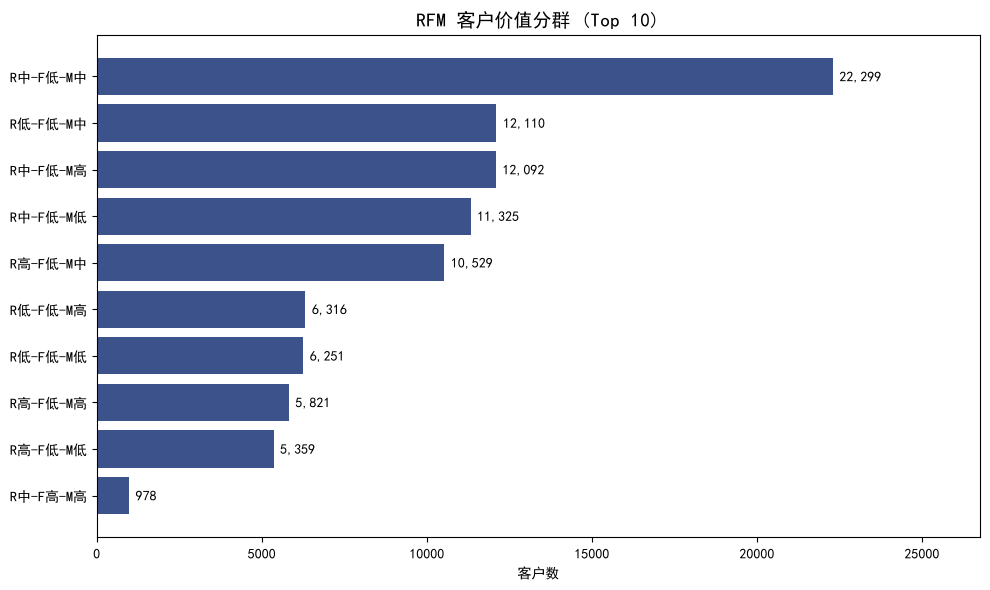

In [164]:
# RFM 分析图
rfm['segment'] = 'R' + rfm['R_level'].astype(str) + '-F' + rfm['F_level'].astype(str) + '-M' + rfm['M_level'].astype(str)
segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['RFM组合', '客户数']

fig, ax = plt.subplots(figsize=(10, 6))
top10 = segment_counts.head(10)
bars = ax.barh(top10['RFM组合'], top10['客户数'], color='#3b528b')
ax.set_xlabel('客户数')
ax.set_title('RFM 客户价值分群 (Top 10)', fontsize=14)
for i, v in enumerate(top10['客户数']):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, top10['客户数'].max() * 1.2)
plt.tight_layout()
plt.show()

In [165]:
# RFM 3D 分析图（pyecharts Bar3D）
# X轴 = Recency × Frequency (6种组合), Y轴 = Monetary (3档), Z轴 = 客户数量
from pyecharts import options as opts
from pyecharts.charts import Bar3D
from pyecharts.globals import ThemeType

rfm_3d = rfm.copy()
rfm_3d['R_level'] = pd.cut(rfm_3d['recency'], bins=[-1, 114, 339, 1000], labels=['高', '中', '低'])
rfm_3d['F_level'] = pd.cut(rfm_3d['frequency'], bins=[0, 1, 20], labels=['低', '高'])
rfm_3d['M_level'] = pd.cut(rfm_3d['monetary'], bins=[-1, 62, 172, 100000], labels=['低', '中', '高'])

grouped = rfm_3d.groupby(['R_level', 'F_level', 'M_level'], observed=False).size().reset_index(name='count')

r_order = ['高', '中', '低']
f_order = ['低', '高']
m_order = ['低', '中', '高']
m_map = {name: i for i, name in enumerate(m_order)}

rf_labels = [f'R{r}-F{f}' for r in r_order for f in f_order]
rf_map = {}
for ri, r in enumerate(r_order):
    for fi, f in enumerate(f_order):
        rf_map[(r, f)] = ri * len(f_order) + fi

data_3d = []
for r in r_order:
    for f in f_order:
        for m in m_order:
            x = rf_map[(r, f)]
            y = m_map[m]
            match = grouped[(grouped['R_level'] == r) & (grouped['F_level'] == f) & (grouped['M_level'] == m)]
            z = int(match['count'].values[0]) if len(match) > 0 else 0
            data_3d.append([x, y, z])

max_count = grouped['count'].max()

bar3d = (
    Bar3D(init_opts=opts.InitOpts(
        width='1200px',
        height='800px',
        theme=ThemeType.LIGHT,
        bg_color='#ffffff',
    ))
    .add(
        series_name='客户数量',
        data=data_3d,
        xaxis3d_opts=opts.Axis3DOpts(
            rf_labels, name='Recency × Frequency', min_=0, max_=5,
            axislabel_opts=opts.LabelOpts(font_size=11),
        ),
        yaxis3d_opts=opts.Axis3DOpts(
            [f'M{m}' for m in m_order], name='Monetary', min_=0, max_=2,
            axislabel_opts=opts.LabelOpts(font_size=12),
        ),
        zaxis3d_opts=opts.Axis3DOpts(
            name='客户数量', min_=0, max_=int(max_count * 1.15),
            axislabel_opts=opts.LabelOpts(font_size=10),
        ),
        grid3d_opts=opts.Grid3DOpts(
            width=100, depth=100, height=100,
            is_rotate=False, rotate_speed=10,
            view_control_alpha=20, view_control_beta=50,
        ),
        itemstyle_opts=opts.ItemStyleOpts(opacity=0.9),
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title='RFM 客户价值 3D 分析',
            subtitle='X=Recency×Frequency(6组合), Y=Monetary(3档), 柱高=客户数量',
            pos_left='center', pos_top='2%',
            title_textstyle_opts=opts.TextStyleOpts(font_size=20, color='#222', font_weight='bold'),
            subtitle_textstyle_opts=opts.TextStyleOpts(font_size=13, color='#666'),
        ),
        visualmap_opts=opts.VisualMapOpts(
            max_=int(max_count),
            range_color=['#313695', '#74add1', '#abd9e9', '#fee090', '#f46d43', '#a50026'],
            pos_right='3%', pos_top='10%',
        ),
        tooltip_opts=opts.TooltipOpts(trigger='item'),
    )
)

# 同时保存HTML文件和在notebook内渲染
bar3d.render('rfm_3d.html')
print('3D图已生成: rfm_3d.html')
bar3d.render_notebook()


3D图已生成: rfm_3d.html


**分析结论：**
- 18 种 RFM 组合中，"中-低-中"（近半年购买、仅买1次、中等消费）客户最多（22,299人），占 23.5%
- "低-低-中"（超过半年未买、仅买1次、中等消费）和"中-低-高"（近半年购买、仅买1次、高消费）紧随其后，分别为 12,110 人和 12,092 人
- "高-低-高"（近期购买、仅买1次、高消费）有 5,821 人，是高价值新客，需重点维护
- F=高（复购客户）仅占 3.04%，与复购率分析结果一致
- 客户群体以一次性、中等消费为主，缺乏忠诚度高的高频客户
- 建议：针对"高-低-高"客户推送个性化推荐，提升复购率；对"低-低-中"客户做召回营销

- 8. 类目销售分析

In [166]:
# print(items.head())
print(items.shape)
items.nunique()
# items['category_en'].nunique()

(112650, 10)


order_id                         98666
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
product_category_name               73
product_category_name_english       71
category_en                         74
dtype: int64

In [167]:
# 类目销售分析
category_sales = items.groupby('category_en').agg(
    order_count=('order_id', 'nunique'),
    revenue=('price', 'sum'),
).reset_index()
# category_sales.head()
category_sales['revenue_share'] = (category_sales['revenue'] / category_sales['revenue'].sum() * 100).round(2)
category_sales = category_sales.sort_values('revenue', ascending=False).head(10)
category_sales

,category_en,order_count,revenue,revenue_share
43,health_beauty,8836,1258681.34,9.26
73,watches_gifts,5624,1205005.68,8.87
7,bed_bath_table,9417,1036988.68,7.63
67,sports_leisure,7720,988048.97,7.27
15,computers_accessories,6689,911954.32,6.71
39,furniture_decor,6449,729762.49,5.37
20,cool_stuff,3632,635290.85,4.67
49,housewares,5884,632248.66,4.65
5,auto,3897,592720.11,4.36
42,garden_tools,3518,485256.46,3.57


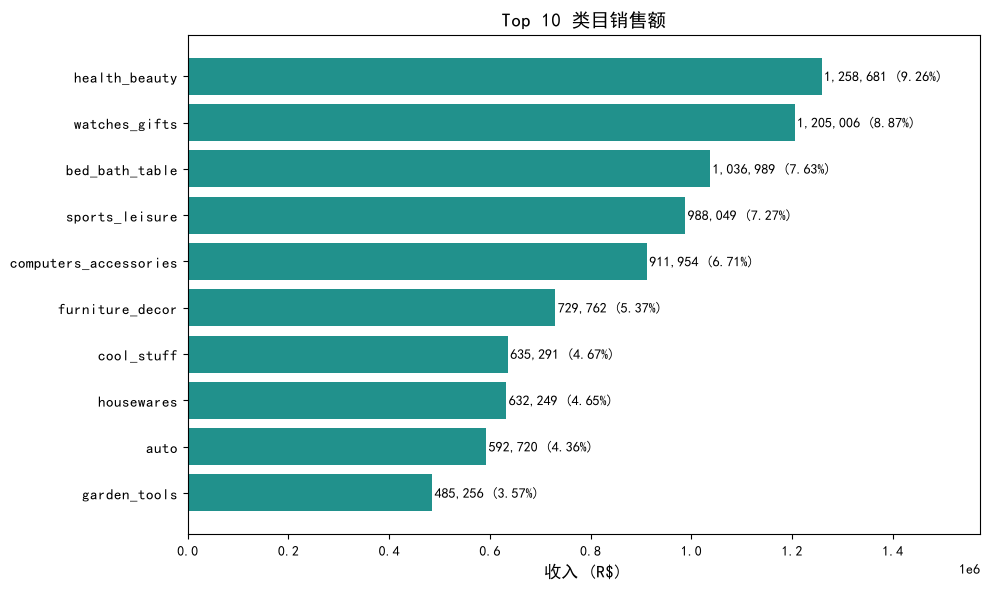

In [168]:
# 类目销售分析图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(category_sales['category_en'], category_sales['revenue'], color='#21918c')
ax.set_xlabel('收入 (R$)', fontsize=12)
ax.set_title('Top 10 类目销售额', fontsize=14)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
for i, (v, share) in enumerate(zip(category_sales['revenue'], category_sales['revenue_share'])):
    ax.text(v + 5000, i, f'{v:,.0f} ({share}%)', va='center', fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, category_sales['revenue'].max() * 1.25)
plt.tight_layout()
plt.show()

**分析结论：**
- health_beauty（健康美容）以 R$1,258,681 占据 9.26% 收入份额，是第一大类目
- watches_gifts（手表礼品）和 bed_bath_table（床浴桌）紧随其后，分别占 8.87% 和 7.63%
- 前 5 大类目合计贡献约 39.74% 的收入，头部效应明显但长尾类目同样分散
- sports_leisure（运动休闲）和 computers_accessories（电脑配件）也表现强劲，分别占 7.27% 和 6.71%
- 建议：加大 top 5 类目的库存和推广投入，长尾类目保持基础运营即可